In [46]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [47]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [48]:
df.shape

(569, 33)

In [49]:
df.drop(columns=['id', 'Unnamed: 32'], inplace= True)

In [50]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [51]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
255,13.960,17.05,91.43,602.4,0.10960,0.12790,0.09789,0.052460,0.1908,0.06130,...,16.390,22.07,108.10,826.0,0.1512,0.32620,0.32090,0.13740,0.3068,0.07957
51,13.640,16.34,87.21,571.8,0.07685,0.06059,0.01857,0.017230,0.1353,0.05953,...,14.670,23.19,96.08,656.7,0.1089,0.15820,0.10500,0.08586,0.2346,0.08025
412,9.397,21.68,59.75,268.8,0.07969,0.06053,0.03735,0.005128,0.1274,0.06724,...,9.965,27.99,66.61,301.0,0.1086,0.18870,0.18680,0.02564,0.2376,0.09206
246,13.200,17.43,84.13,541.6,0.07215,0.04524,0.04336,0.011050,0.1487,0.05635,...,13.940,27.82,88.28,602.0,0.1101,0.15080,0.22980,0.04970,0.2767,0.07198
100,13.610,24.98,88.05,582.7,0.09488,0.08511,0.08625,0.044890,0.1609,0.05871,...,16.990,35.27,108.60,906.5,0.1265,0.19430,0.31690,0.11840,0.2651,0.07397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,11.080,14.71,70.21,372.7,0.10060,0.05743,0.02363,0.025830,0.1566,0.06669,...,11.350,16.82,72.01,396.5,0.1216,0.08240,0.03938,0.04306,0.1902,0.07313
299,10.510,23.09,66.85,334.2,0.10150,0.06797,0.02495,0.018750,0.1695,0.06556,...,10.930,24.22,70.10,362.7,0.1143,0.08614,0.04158,0.03125,0.2227,0.06777
373,20.640,17.35,134.80,1335.0,0.09446,0.10760,0.15270,0.089410,0.1571,0.05478,...,25.370,23.17,166.80,1946.0,0.1562,0.30550,0.41590,0.21120,0.2689,0.07055
547,10.260,16.58,65.85,320.8,0.08877,0.08066,0.04358,0.024380,0.1669,0.06714,...,10.830,22.04,71.08,357.4,0.1461,0.22460,0.17830,0.08333,0.2691,0.09479


In [52]:
y_train

255    M
51     B
412    B
246    B
100    M
      ..
173    B
299    B
373    M
547    B
131    M
Name: diagnosis, Length: 455, dtype: object

In [53]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
X_train

array([[-0.01945268, -0.50116446,  0.00677673, ...,  0.38076401,
         0.28425679, -0.23793333],
       [-0.1112796 , -0.66431867, -0.16880019, ..., -0.41139207,
        -0.94236115, -0.19770262],
       [-1.32884722,  0.56278478, -1.31129838, ..., -1.33695743,
        -0.89139365,  0.5010102 ],
       ...,
       [ 1.89743435, -0.43222607,  1.8112249 , ...,  1.51505035,
        -0.35963269, -0.7715819 ],
       [-1.08120148, -0.60916795, -1.05750235, ..., -0.45027749,
        -0.35623485,  0.66252468],
       [ 0.41098603,  0.05723655,  0.43406939, ...,  0.59594028,
        -0.108193  , -0.20125238]])

In [55]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [56]:
y_train

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,

In [57]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_test_tensor = torch.from_numpy(y_test).float()

In [58]:
X_train_tensor

tensor([[-0.0195, -0.5012,  0.0068,  ...,  0.3808,  0.2843, -0.2379],
        [-0.1113, -0.6643, -0.1688,  ..., -0.4114, -0.9424, -0.1977],
        [-1.3288,  0.5628, -1.3113,  ..., -1.3370, -0.8914,  0.5010],
        ...,
        [ 1.8974, -0.4322,  1.8112,  ...,  1.5151, -0.3596, -0.7716],
        [-1.0812, -0.6092, -1.0575,  ..., -0.4503, -0.3562,  0.6625],
        [ 0.4110,  0.0572,  0.4341,  ...,  0.5959, -0.1082, -0.2013]])

In [59]:
X_train_tensor.shape

torch.Size([455, 30])

In [60]:
class MySimpleNN():

  def __init__(self, X):

    self.weights = torch.rand(X.shape[1], 1, dtype=torch.float64, requires_grad=True)
    self.bias = torch.zeros(1, dtype=torch.float64, requires_grad=True)

  def forward(self, X):
    z = torch.matmul(X, self.weights) + self.bias
    y_pred = torch.sigmoid(z)
    return y_pred

  def loss_function(self, y_pred, y):
    # Clamp predictions to avoid log(0)
    epsilon = 1e-7
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    # Calculate loss
    loss = -(y_train_tensor * torch.log(y_pred) + (1 - y_train_tensor) * torch.log(1 - y_pred)).mean()
    return loss


In [61]:
learning_rate = 0.1
epochs = 25

In [63]:
# create model
model = MySimpleNN(X_train_tensor)

# define loop
for epoch in range(epochs):

  # forward pass
  y_pred = model.forward(X_train_tensor)

  # loss calculate
  loss = model.loss_function(y_pred, y_train_tensor)

  # backward pass
  loss.backward()

  # parameters update
  with torch.no_grad():
    model.weights -= learning_rate * model.weights.grad
    model.bias -= learning_rate * model.bias.grad

  # zero gradients
  model.weights.grad.zero_()
  model.bias.grad.zero_()

  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

RuntimeError: expected m1 and m2 to have the same dtype, but got: float != double

In [ ]:
# model evaluation
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.9).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')


| PyTorch Module | What does it do? |
|----------------|------------------|
| **`torch.nn`** | Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way). |
| **`torch.nn.Parameter`** | Stores tensors that can be used with `nn.Module`. If `requires_grad=True`, gradients (used for updating model parameters via gradient descent) are calculated automatically. This automatic differentiation system is often referred to as **autograd**. |
| **`torch.nn.Module`** | The base class for all neural network modules. All the building blocks for neural networks are subclasses of `nn.Module`. If you're building a neural network in PyTorch, your model should subclass `nn.Module`. It requires a `forward()` method to be implemented. |
| **`torch.optim`** | Contains various optimization algorithms. These tell the model parameters stored in `nn.Parameter` how to update themselves to minimize the loss using gradient descent (or one of its variants). |
| **`forward()`** | Every subclass of `nn.Module` must implement a `forward()` method. It defines the computation performed on the input data (e.g., for linear regression, `y = wx + b`). Calling `model(x)` automatically invokes `model.forward(x)`. |

In [ ]:
import torch.nn as nn

In [ ]:
class Model(nn.Module):

    def __init__(self, num_features):
        super().__init__();
        self.linear = nn.Linear(num_features, 1) # num of features and num of outputs
        self.sigmoid = nn.Sigmoid()


    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)

        return out

In [ ]:
features = torch.rand(10, 5)

model = Model(features.shape[1])

model(features)


In [ ]:
from torchinfo import summary

summary(model, input_size = (10, 5))

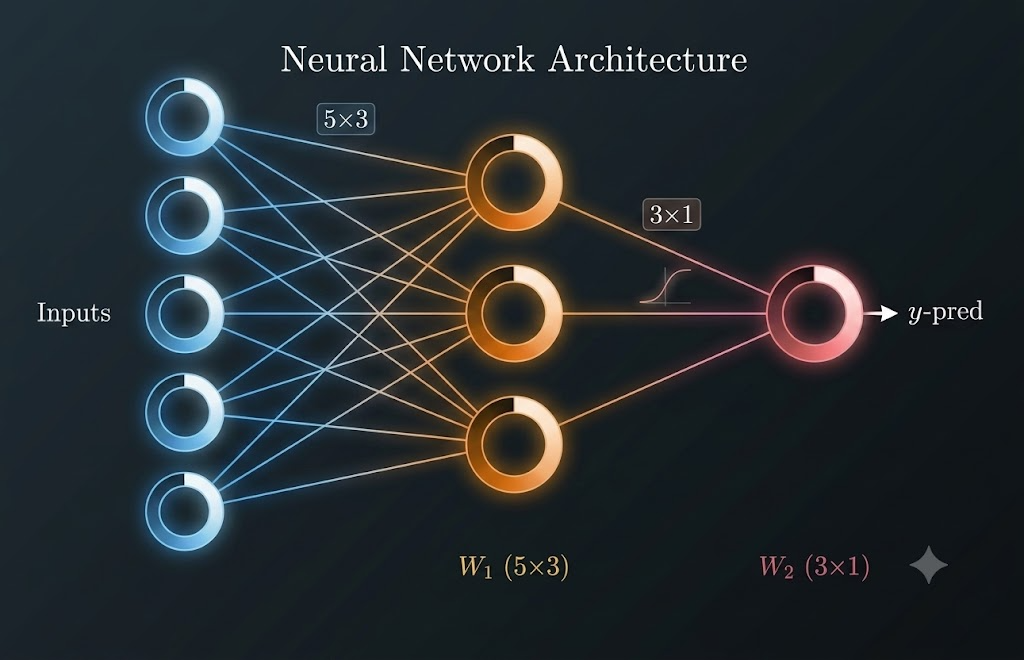

In [ ]:
class MLP(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        # define layers
        self.layer1 = nn.Linear(num_features, 3)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, features):
        out = self.layer1(features)
        out = self.relu(out)
        out = self.layer2(out)
        out = self.sigmoid(out)

        return out

In [ ]:
model_adv = MLP(features.shape[1])

model_adv(features)

In [ ]:
model_adv.layer1.weight

In [ ]:
class MLP_seq(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        # define layers
        self.network = nn.Sequential(nn.Linear(num_features, 3),
        nn.ReLU(),
        nn.Linear(3, 1),
        nn.Sigmoid())

    def forward(self, features):
        out = self.network(features)

        return out

In [64]:
model_seq = MLP_seq(features.shape[1])

model_seq(features)

NameError: name 'MLP_seq' is not defined

In [ ]:
class ANN(nn.Module):

  def __init__(self, num_features):

      super().__init__()
      self.linear = nn.Linear(num_features, 1)
      self.sigmoid = nn.Sigmoid()
      
  def forward(self, features):
      out = self.linear(features)
      out = self.sigmoid(out)

      return out


In [ ]:
# create model
model = ANN(X_train_tensor.shape[1])
loss_function = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
# define loop
for epoch in range(epochs):

  # forward pass
  # batch gradient descent
  y_pred = model(X_train_tensor)
  # loss calculate
  loss = loss_function(y_pred, y_train_tensor.view(-1, 1))

  optimizer.zero_grad()
  
  loss.backward()

  optimizer.step() #parameter update
  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

## Mini batch gradient descent using Dataset and Dataloader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = features
    self.labels = labels

  def __len__(self):

    return len(self.features)

  def __getitem__(self, idx):

    return self.features[idx], self.labels[idx]



In [ ]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

In [ ]:
train_dataset[10]

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [ ]:
model = ANN(X_train_tensor.shape[1])
loss_function = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)


# define loop
for epoch in range(epochs):

  for batch_features, batch_labels in train_loader:

    # forward pass
    y_pred = model(batch_features)

    # loss calculate
    loss = loss_function(y_pred, batch_labels.view(-1,1))

    # clear gradients
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # parameters update
    optimizer.step()

  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

In [ ]:
# Model evaluation using test_loader
model.eval()  # Set the model to evaluation mode
accuracy_list = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # Forward pass
        y_pred = model(batch_features)
        y_pred = (y_pred > 0.8).float()  # Convert probabilities to binary predictions

        # Calculate accuracy for the current batch
        batch_accuracy = (y_pred.view(-1) == batch_labels).float().mean().item()
        accuracy_list.append(batch_accuracy)

# Calculate overall accuracy
overall_accuracy = sum(accuracy_list) / len(accuracy_list)
print(f'Accuracy: {overall_accuracy:.4f}')
